# Advanced Python Analysis – Feature Engineering & Model Readiness

## Project: IBM HR Analytics – Employee Attrition & Performance

This notebook focuses on **advanced data preparation and feature analysis**
required before applying machine learning models.

The objective of this step is to:
- Transform business insights into **model-ready features**
- Encode categorical variables correctly
- Analyze numerical distributions and correlations
- Identify the most influential factors contributing to employee attrition

This step acts as the **bridge between Exploratory Data Analysis (EDA)**
and **Predictive Modeling (Data Science)**.


## 1. Import Required Libraries

We begin by importing essential Python libraries used for:
- Data manipulation
- Numerical operations
- Visualization
- Feature analysis

These libraries form the foundation of most data science workflows.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

## 2. Load Cleaned Dataset

We load the cleaned HR dataset prepared in the previous step.
This dataset has already undergone:
- Basic validation
- Structural checks
- Missing value inspection

At this stage, our focus shifts from data quality to **data usability for ML**.


In [3]:
df = pd.read_csv("../01_dataset/raw/IBM_HR_Analytics_Employee_Attrition_Performance.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Dataset Overview (Advanced Perspective)

Before feature engineering, we re-examine:
- Dataset shape
- Data types
- Redundant or non-informative columns

Some columns may exist purely for record-keeping and provide **no predictive value**.
Removing them improves model performance and interpretability.


In [4]:
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 4. Removing Non-Predictive Columns

The following columns do not contribute to attrition prediction:

- EmployeeCount (constant value)
- EmployeeNumber (unique identifier)
- StandardHours (constant value)

Such columns add noise and increase dimensionality
without improving predictive power.


In [6]:
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'StandardHours']
df.drop(columns=drop_cols, inplace=True)

In [7]:
df.shape

(1470, 32)

## 5. Target Variable Encoding

Machine learning models require numerical target variables.

We encode:
- Attrition = Yes → 1
- Attrition = No  → 0

|

In [8]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

## 6. Identifying Feature Types

For correct preprocessing, we separate:
- Categorical features → require encoding
- Numerical features → may require scaling or transformation

This separation ensures appropriate handling of each variable type.


In [9]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(exclude='object').columns.tolist()

categorical_cols, numerical_cols

(['BusinessTravel',
  'Department',
  'EducationField',
  'Gender',
  'JobRole',
  'MaritalStatus',
  'Over18',
  'OverTime'],
 ['Age',
  'Attrition',
  'DailyRate',
  'DistanceFromHome',
  'Education',
  'EnvironmentSatisfaction',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobSatisfaction',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'PercentSalaryHike',
  'PerformanceRating',
  'RelationshipSatisfaction',
  'StockOptionLevel',
  'TotalWorkingYears',
  'TrainingTimesLastYear',
  'WorkLifeBalance',
  'YearsAtCompany',
  'YearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager'])

## 7. Encoding Categorical Variables

We apply **Label Encoding** to convert categorical values into numerical form.

Label Encoding is suitable here because:
- Most features are ordinal or low-cardinality
- Tree-based models (planned later) handle label encoding well

For linear models, one-hot encoding may be applied later if required.


In [10]:
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])


In [12]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1302,35,0,2,185,1,23,4,3,2,1,...,3,2,1,6,2,4,5,4,0,3
435,33,1,2,1277,1,15,1,3,2,1,...,3,4,0,15,2,4,7,6,7,7
1457,40,0,2,1194,1,2,4,3,3,0,...,3,2,3,20,2,3,5,3,0,2
789,44,1,2,1376,0,1,2,3,2,1,...,3,4,1,24,1,3,20,6,3,6
929,28,0,1,193,1,2,3,1,4,1,...,3,2,1,2,2,3,2,2,2,2


## 8. Numerical Feature Distribution Analysis

Understanding feature distributions helps identify:
- Skewness
- Outliers
- Scale differences

These insights guide transformations such as:
- Log scaling
- Normalization
- Outlier treatment


In [13]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


## 9. Correlation Analysis

Correlation analysis helps:
- Identify strong relationships with attrition
- Detect multicollinearity between features
- Select important predictors

We visualize correlations using a heatmap.


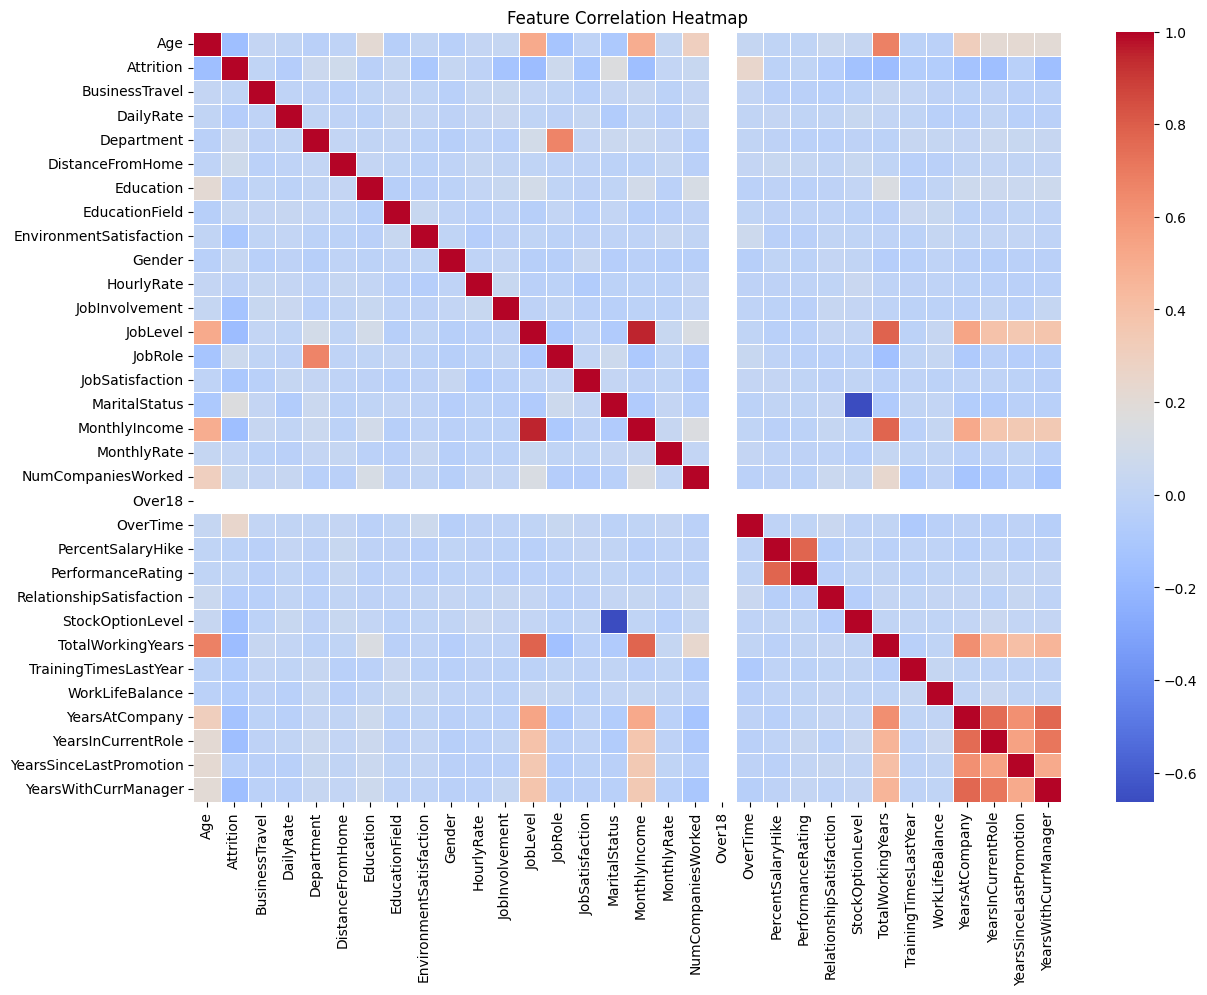

In [14]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## 10. Features Most Correlated with Attrition

Ranking correlations with the target variable
provides an early indication of feature importance.

This does NOT replace modeling,
but helps prioritize impactful variables.


In [15]:
attrition_corr = df.corr()['Attrition'].sort_values(ascending=False)
attrition_corr

Attrition                   1.000000
OverTime                    0.246118
MaritalStatus               0.162070
DistanceFromHome            0.077924
JobRole                     0.067151
Department                  0.063991
NumCompaniesWorked          0.043494
Gender                      0.029453
EducationField              0.026846
MonthlyRate                 0.015170
PerformanceRating           0.002889
BusinessTravel              0.000074
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
M

## 11. Feature Engineering Summary

Key outcomes of this step:

- Removed non-informative columns
- Encoded categorical features
- Identified strong attrition drivers such as:
  - Monthly Income
  - OverTime
  - Job Role
  - Years at Company
  - Work-Life Balance

The dataset is now **clean, structured, and model-ready**.


## Next Step

Proceed to **Step 08 – Visualization & Storytelling**,
where we translate analytical results into
clear, business-friendly insights using visualizations.
